In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('../data/train.csv')

In [19]:
# print(df.shape)
# df.head()
# df.info()
# df.describe()

# df.dtypes.value_counts()

df.isna().sum().sort_values()

Id                0
MSSubClass        0
MSZoning          0
LotArea           0
LotShape          0
               ... 
MasVnrType      872
Fence          1179
Alley          1369
MiscFeature    1406
PoolQC         1453
Length: 81, dtype: int64

Dataset Size - (1460, 81) 

Target Variable - SalePrice
    Range - (34900, 755000)

Data Types
    numerical features - 38
    categorical features - 43

Missing Values
    columns with a lot of nulls - Fence, Alley, MiscFeature, PoolQC


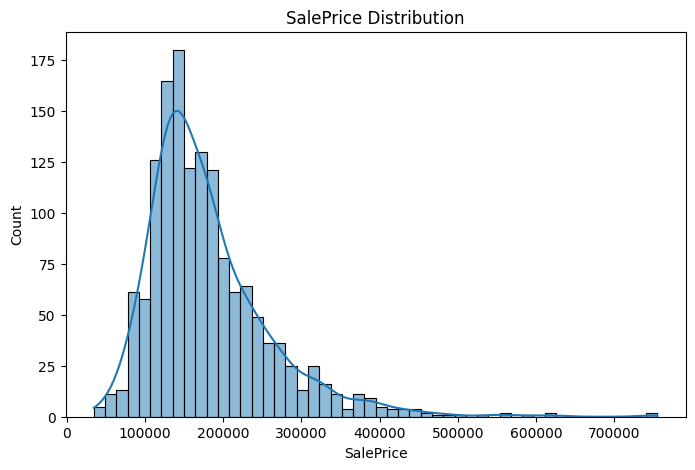

Mean:  180921.19589041095
Median:  163000.0
Skew:  1.8828757597682129


In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], bins=50, kde=True)
plt.title("SalePrice Distribution")
plt.show()

print("Mean: ", df['SalePrice'].mean())
print("Median: ", df['SalePrice'].median())
print("Skew: ", df['SalePrice'].skew())


Shape - skewed towards right
Mean vs Median - Mean is larger, values towards the right are larger and pull the mean towards right
Skew Value - 1.88 - positive - strong right skew

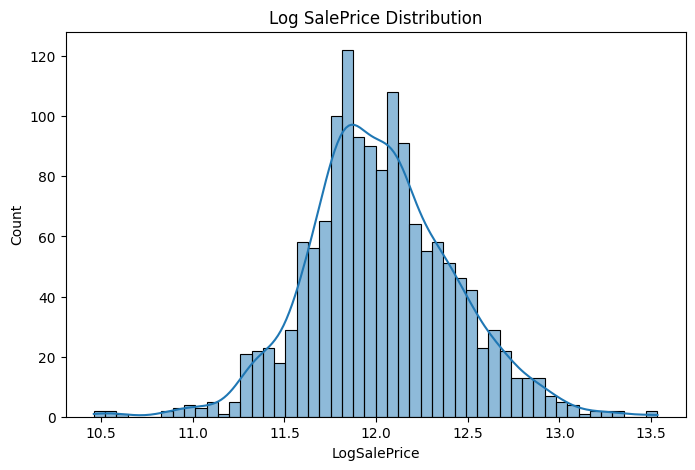

Skew after log:  0.12133506220520406


In [7]:
df["LogSalePrice"] = np.log(df['SalePrice'])

plt.figure(figsize=(8,5))
plt.title('Log SalePrice Distribution')
sns.histplot(df['LogSalePrice'], bins=50, kde=True)
plt.show()

print("Skew after log: ", df["LogSalePrice"].skew())

Shape after log - more symmetric

Skew value change - reduced to 0.12 - more moderate

Log helps because it doesn't change the data in terms of values what's is increasing before is still increasing. It transforms higher values into moderately higher values reducing the gap between distribution. For example, 1, 10, 100, 1000 becomes 0, 1, 2, 3 after log application. It brings the distribution closer. Most regression models implicitly assume errors are symmetric and not dominated by extreme values. With log, relative differences matter more than absolute differences and model becomes more stable.

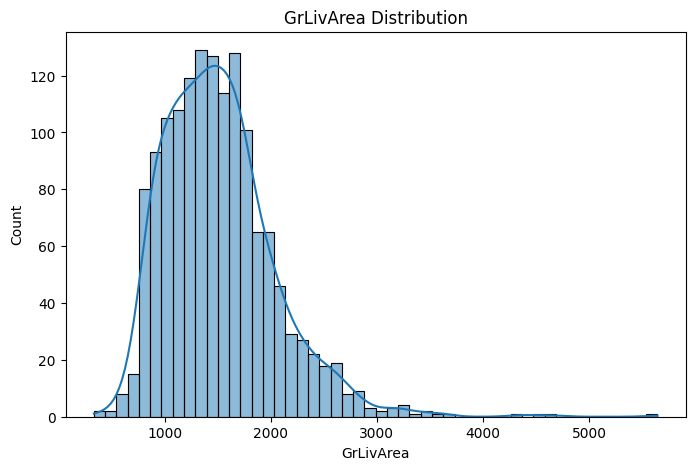

GrLivArea Skew:  1.3665603560164552


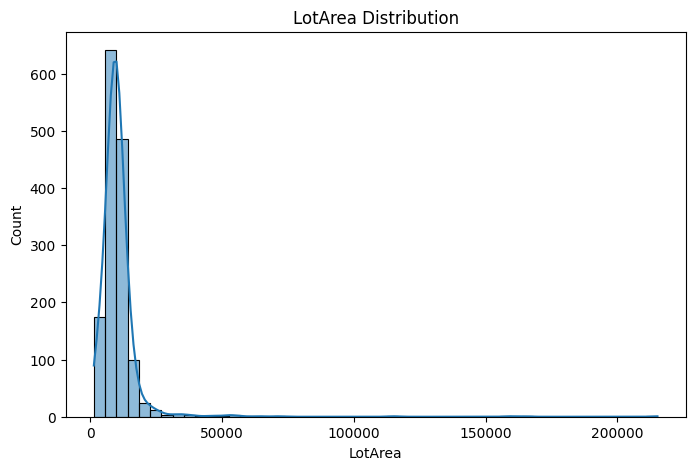

LotArea Skew:  12.207687851233496


In [25]:
features = ['GrLivArea', 'LotArea']

for col in features:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

    print(col, "Skew: ", df[col].skew())

GrLivArea Skew:  1.3665603560164552
Shape - skewed
Skew value - high, greater than one - strong positive right skew
similar behavior to saleprice

LotArea Skew:  12.207687851233496
Shape - skewed
Skew value - extremely high - extremely strong positive right skew
Similar behavior to saleprice with extreme intensity 

In [26]:
df["LogLotArea"] = np.log(df["LotArea"])

CONDITIONAL DISTRIBUTIONS

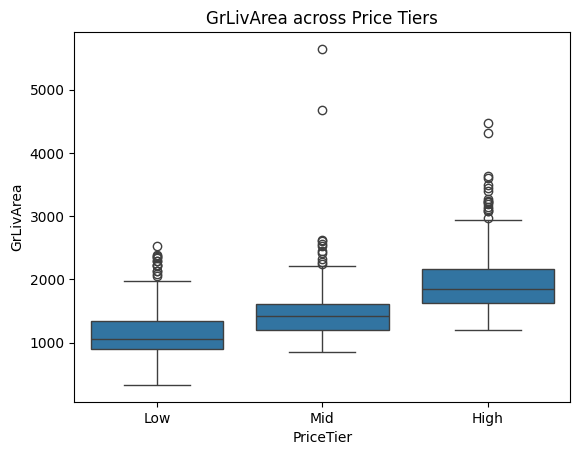

In [27]:
df["PriceTier"] = pd.qcut(df['SalePrice'], q=3, labels=['Low', 'Mid', 'High'])

sns.boxplot(x='PriceTier', y='GrLivArea', data=df)
plt.title('GrLivArea across Price Tiers')
plt.show()

In [28]:
from scipy.stats import entropy

# Discretize into bins
bins = 30

low = df[df["PriceTier"] == "Low"]["GrLivArea"]
high = df[df["PriceTier"] == "High"]["GrLivArea"]

# Histogram densities
p, bin_edges = np.histogram(low, bins=bins, density=True)
q, _ = np.histogram(high, bins=bin_edges, density=True)

# Avoid zeros
p = p + 1e-10
q = q + 1e-10

kl_low_high = entropy(p, q)

print("KL(Low || High):", kl_low_high)

KL(Low || High): 9.57855628664652


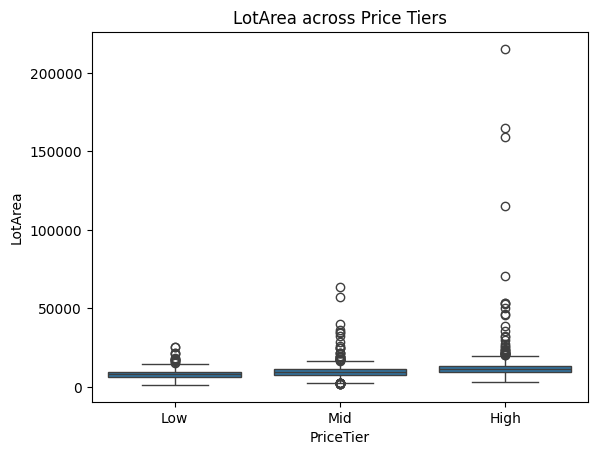

In [30]:
df["PriceTier"] = pd.qcut(df['SalePrice'], q=3, labels=['Low', 'Mid', 'High'])

sns.boxplot(x='PriceTier', y='LotArea', data=df)
plt.title('LotArea across Price Tiers')
plt.show()

In [29]:
# Discretize into bins
bins = 30

low = df[df["PriceTier"] == "Low"]["LotArea"]
high = df[df["PriceTier"] == "High"]["LotArea"]

# Histogram densities
p, bin_edges = np.histogram(low, bins=bins, density=True)
q, _ = np.histogram(high, bins=bin_edges, density=True)

# Avoid zeros
p = p + 1e-10
q = q + 1e-10

la_kl_low_high = entropy(p, q)

print("KL(Low || High):", la_kl_low_high)

KL(Low || High): 1.4545250185748306


SIMPLE LINEAR REGRESSION 

In [5]:
from sklearn.linear_model import LinearRegression

X = df[['GrLivArea']]
y = df['SalePrice']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

residuals = y - y_pred



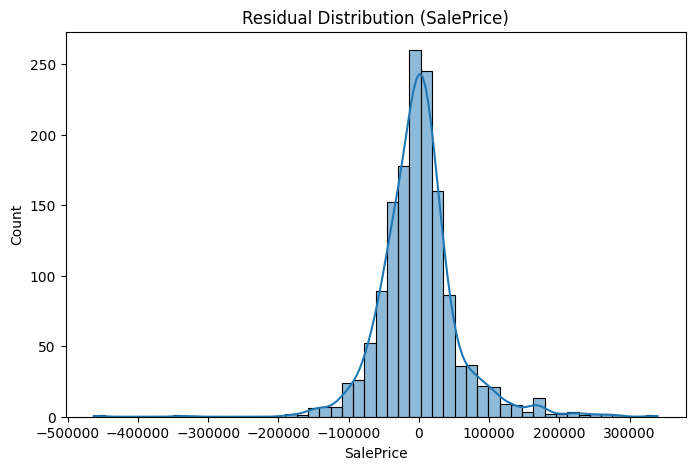

Skew:  0.41022413183917616


In [6]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)
plt.title('Residual Distribution (SalePrice)')
plt.show()

print("Skew: ", residuals.skew())

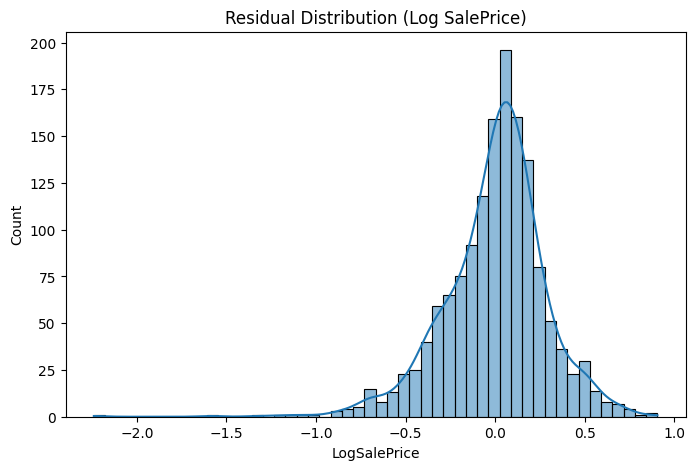

Residual skew (log): -0.8766624043820604


In [8]:
X = df[["GrLivArea"]]
y_log = df["LogSalePrice"]

model_log = LinearRegression()
model_log.fit(X, y_log)

y_log_pred = model_log.predict(X)

residuals_log = y_log - y_log_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals_log, bins=50, kde=True)
plt.title("Residual Distribution (Log SalePrice)")
plt.show()

print("Residual skew (log):", residuals_log.skew())

More symmetric after applying log - centered near zero

skew reduced to less than 0 - left skewed

Log transform improved the residuals because the extreme prices are reduced and the model fitted on relative differences rather than absolute differences